# 3 — H2: threshold-like collapse

**Degradation is nonlinear in compression pressure.** Recall stays relatively stable
while the recurrent state has spare capacity, then drops sharply once it saturates,
rather than declining smoothly throughout.

Two tests, both anchored on the published threshold T:

1. **Drop at T** — accuracy below T versus at or above it, with a clustered bootstrap
   interval.
2. **Shape** — a fit allowed to break at T against a single smooth fit. If the smooth
   fit does as well, degradation is gradual and H2 is refuted.

**T comes from a published paper, never from our data.** Estimating the changepoint from
our own curves would be self-defining the threshold, which the mentor ruled out — it
would force an extra sensitivity-analysis table we have no page budget for.
`config.compression_threshold` raises until the decision record in
`protocol/h2_threshold.md` is `LOCKED`, so the H2 columns render blank rather than
quietly filling with a number we picked.

This notebook also carries the architecture comparison, since Mamba2, DeltaNet and
GatedDeltaNet are compared on exactly this curve.

In [3]:
import sys
from pathlib import Path

here = Path.cwd().resolve()
ROOT = next((p for p in (here, *here.parents) if (p / "config").exists()), here)
sys.path.insert(0, str(ROOT / "src"))

import pandas as pd
from ahnexp import config, h2_threshold, report, schema, stats

MODE = "pilot"
SOURCE = "synthetic"   # "run" | "pilot_csv" | "synthetic"


def load(source, mode):
    if source == "run":
        return pd.read_parquet(config.output_path("raw", mode)), False
    if source == "pilot_csv":
        # One arm only, so the architecture comparison below will be empty.
        return schema.from_pilot_csv(
            ROOT / "data/pilot_raw_results.csv",
            architecture="gated_deltanet",
            sliding_window=256,
        ), False
    from ahnexp._smoke import fake_results
    return fake_results(), True


df, SYNTHETIC = load(SOURCE, MODE)
WINDOW = int(df["sliding_window"].iloc[0])
T = config.compression_threshold(strict=False)
print(f"{len(df)} trials · {df['architecture'].nunique()} arm(s) · synthetic={SYNTHETIC}")
print(f"window = {WINDOW} tokens · T = {T} tokens = {T / WINDOW:.1f} windows")
stats.assert_matched_design(df)

2880 trials · 4 arm(s) · synthetic=True
window = 256 tokens · T = 768 tokens = 3.0 windows


## Degradation curves per architecture

The paper's main graph. The dotted line at 1.0 is the window edge, where the target
leaves exact attention; the dashed red line is the published threshold T.

The `transformer` arm has no compressed memory at all — past the window the target is
simply gone. It is the floor the AHN arms must beat, not a competitor.

architecture,deltanet,gated_deltanet,mamba2,transformer
tokens_after_target,,,,
0,0.775,0.712,0.788,0.738
64,0.850,0.700,0.825,0.775
128,0.762,0.762,0.812,0.688
256,0.812,0.838,0.875,0.762
512,0.650,0.575,0.675,0.338
768,0.388,0.638,0.562,0.200
1024,0.312,0.550,0.388,0.062
2048,0.075,0.412,0.162,0.038
4096,0.038,0.250,0.012,0.000


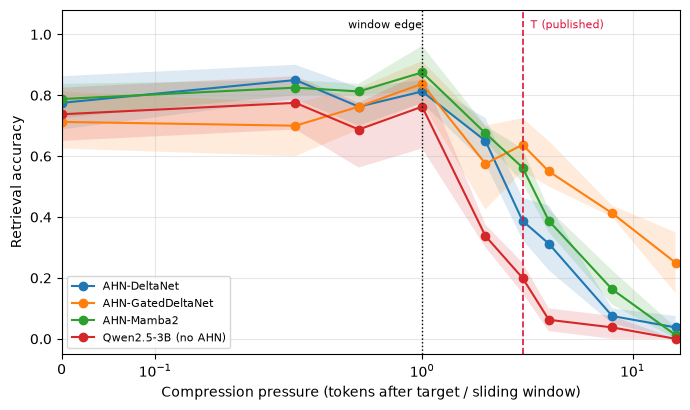

In [4]:
%matplotlib inline
curves = h2_threshold.curves(df)
report.plot_curves(
    curves,
    group_col="architecture",
    path=config.figure_path("h2_degradation_by_architecture", MODE),
)
curves.pivot(index="tokens_after_target", columns="architecture", values="accuracy").round(3)

## The two H2 tests

These use `strict=False` so the shape can be inspected before the citation lands. The
tables written at the bottom use the strict path and stay blank until decision #3 closes
— that is deliberate, so an unsourced threshold cannot reach a draft by accident.

`drop_at_T` is the size of the collapse; `shape` says whether a break at T explains the
curve better than a single smooth trend. H2 needs both: a large drop with a smooth
verdict just means degradation is steep, not threshold-like.

In [3]:
print("drop at T:")
print(h2_threshold.drop_at_threshold(df, threshold_tokens=T).round(3).to_string(index=False))
print("\nshape (piecewise-at-T vs single smooth fit, lower AIC wins):")
print(h2_threshold.shape_test(df, threshold_tokens=T).round(3).to_string(index=False))

drop at T:
  architecture  threshold_tokens  acc_below_T  acc_above_T  drop_at_T  ci_low  ci_high  n_below  n_above
      deltanet               768        0.770        0.203      0.567   0.529    0.608      400      320
gated_deltanet               768        0.718        0.462      0.255   0.199    0.295      400      320
        mamba2               768        0.795        0.281      0.514   0.480    0.548      400      320
   transformer               768        0.660        0.075      0.585   0.524    0.647      400      320

shape (piecewise-at-T vs single smooth fit, lower AIC wins):
  architecture  rss_smooth  rss_piecewise  aic_smooth  aic_piecewise        verdict
      deltanet       2.559          0.386      -5.119        -16.245 threshold-like
gated_deltanet       1.519          0.887      -9.291         -9.596 threshold-like
        mamba2       6.655          1.030       2.528         -8.402 threshold-like
   transformer      58.211         20.746      19.877         15.6

## Architecture comparison

Paired differences on shared trials, under recurrent memory only. Arms answer the same
items, so differencing removes item difficulty and tightens the intervals considerably.

`deltanet` vs `gated_deltanet` is the cleanest pair: one gating mechanism apart, about
1% apart in parameters. Any AHN arm versus `transformer` is a different claim — that
compressed memory beats no memory — and is expected to be large.

AHN module sizes span 10% (11.8M / 11.9M / 13.0M), and GatedDeltaNet is the largest.
Part of any GDN advantage is capacity, not mechanism. Report the parameter column beside
the result rather than hiding it.

In [5]:
if df["architecture"].nunique() > 1:
    comparisons = h2_threshold.architecture_comparisons(df)
    print(comparisons.round(3).to_string(index=False))
else:
    print(f"only {df['architecture'].iloc[0]} in this run — no comparison to make")

         arm_a          arm_b        condition  mean_difference  ci_low  ci_high  n_pairs
      deltanet gated_deltanet recurrent_memory           -0.165  -0.198   -0.129      480
      deltanet         mamba2 recurrent_memory           -0.067  -0.092   -0.042      480
gated_deltanet         mamba2 recurrent_memory            0.098   0.075    0.131      480
      deltanet    transformer recurrent_memory            0.146   0.104    0.204      480
gated_deltanet    transformer recurrent_memory            0.310   0.271    0.350      480
        mamba2    transformer recurrent_memory            0.212   0.190    0.244      480


## H2 table and gates

`h2_status` reads `THRESHOLD_NOT_LOCKED` and the T columns stay blank until
`protocol/h2_threshold.md` is completed and `config/experiment.yaml` is set to
`status: LOCKED`. That is the gate working, not a bug.

In [6]:
summary = h2_threshold.summary(df)

path = report.write_table(
    summary,
    name="h2_architecture_threshold",
    title="H2 — Threshold-like collapse and architecture comparison",
    mode=MODE,
    synthetic=SYNTHETIC,
    notes=[
        f"Window = {WINDOW} tokens; T = {T} tokens ({T / WINDOW:.1f} windows).",
        "Paired cluster bootstrap on seed; arms answer identical items.",
        "AHN module sizes differ by up to 10% — part of any GDN gain is capacity.",
    ],
)
print("wrote", path.relative_to(ROOT), "\n")
print(report.gate_report(df).to_string(index=False))
summary.round(3)

wrote outputs/tables/h2_architecture_threshold_pilot.md 

                   gate          scope verdict                                                detail
  exact_memory_accuracy       deltanet    PASS                      79.6% inside the defensible band
  exact_memory_accuracy gated_deltanet    PASS                      72.5% inside the defensible band
  exact_memory_accuracy         mamba2    WARN            80.8% above the band, within the 85% bound
  exact_memory_accuracy    transformer    PASS                      73.3% inside the defensible band
     window_is_exceeded         design    PASS 1920/2880 trials past the 256-token window (max 4096)
       threshold_locked             H2 BLOCKED                          H2 threshold T is not locked
threshold_clears_window             H2    PASS                     T=768 tokens = 3.0 windows of 256
          min_cell_size            all    PASS                                all cells large enough
         matched_design          

,architecture,label,ahn_params_m,acc_exact,acc_recurrent,retention,slope,n,acc_below_T,acc_above_T,drop_at_T,shape,h2_status
0,gated_deltanet,AHN-GatedDeltaNet,13.0,0.725,0.544,0.750,-0.619,720,NaN,NaN,NaN,None,THRESHOLD_NOT_LOCKED
1,mamba2,AHN-Mamba2,11.9,0.808,0.446,0.552,-1.513,720,NaN,NaN,NaN,None,THRESHOLD_NOT_LOCKED
2,deltanet,AHN-DeltaNet,11.8,0.796,0.379,0.476,-1.252,720,NaN,NaN,NaN,None,THRESHOLD_NOT_LOCKED
3,transformer,Qwen2.5-3B (no AHN),0.0,0.733,0.233,0.318,-3.292,720,NaN,NaN,NaN,None,THRESHOLD_NOT_LOCKED
